<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Packages" data-toc-modified-id="Packages-0.1"><span class="toc-item-num">0.1&nbsp;&nbsp;</span>Packages</a></span></li><li><span><a href="#Barplot-config" data-toc-modified-id="Barplot-config-0.2"><span class="toc-item-num">0.2&nbsp;&nbsp;</span>Barplot config</a></span></li><li><span><a href="#Load-dump" data-toc-modified-id="Load-dump-0.3"><span class="toc-item-num">0.3&nbsp;&nbsp;</span>Load dump</a></span></li></ul></li><li><span><a href="#Extract-Words" data-toc-modified-id="Extract-Words-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Extract Words</a></span></li><li><span><a href="#Spelling" data-toc-modified-id="Spelling-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Spelling</a></span><ul class="toc-item"><li><span><a href="#Words-with-[p]-,-[m]-,-[lh]-and-[nh]" data-toc-modified-id="Words-with-[p]-,-[m]-,-[lh]-and-[nh]-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Words with [p] , [m] , [lh] and [nh]</a></span><ul class="toc-item"><li><span><a href="#[p]" data-toc-modified-id="[p]-2.1.1"><span class="toc-item-num">2.1.1&nbsp;&nbsp;</span>[p]</a></span></li><li><span><a href="#[m]" data-toc-modified-id="[m]-2.1.2"><span class="toc-item-num">2.1.2&nbsp;&nbsp;</span>[m]</a></span></li><li><span><a href="#[lh]" data-toc-modified-id="[lh]-2.1.3"><span class="toc-item-num">2.1.3&nbsp;&nbsp;</span>[lh]</a></span></li><li><span><a href="#[nh]" data-toc-modified-id="[nh]-2.1.4"><span class="toc-item-num">2.1.4&nbsp;&nbsp;</span>[nh]</a></span></li></ul></li><li><span><a href="#Results" data-toc-modified-id="Results-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Results</a></span></li></ul></li></ul></div>

## Packages

In [1]:
import os
import re

import codecs
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches

## Barplot config

In [2]:
sns.set(color_codes=True)

def show_values_on_bars_v(axs):
    x1,x2,y1,y2 = plt.axis()
    plt.axis((x1,x2,y1 ,y2))
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() - 0.01 + p.get_width() / 2.
            _y = p.get_y() + p.get_height() * 1.02
            value = '{:.3f}%'.format(p.get_height()*100)
            ax.text(_x, _y+0.3, value, ha="center") 

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)
        
def show_values_on_bars_h(axs):
    x1,x2,y1,y2 = plt.axis()
    plt.axis((x1,x2,y1 ,y2))
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() + p.get_width() #+ 0.4
            _y = p.get_y() + p.get_height()
            value = '{:.2f}%'.format(p.get_width()*100)
            ax.text(_x, _y, value, ha="left")

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)
        

def show_values_on_bars_reg_v(axs):
    x1,x2,y1,y2 = plt.axis()
    plt.axis((x1,x2,y1 ,y2 + 8))
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() - 0.01 + p.get_width() / 2.
            _y = p.get_y() + p.get_height() * 1.02
            value = '{:.0f}'.format(p.get_height())
            ax.text(_x, _y+0.3, value, ha="center") 

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)
        
def show_values_on_bars_reg_h(axs):
    x1,x2,y1,y2 = plt.axis()
    plt.axis((x1,x2+8,y1 ,y2))
    def _show_on_single_plot(ax):        
        for p in ax.patches:
            _x = p.get_x() + p.get_width() + 0.4
            _y = p.get_y() + p.get_height()
            value = '{:.0f}'.format(p.get_width())
            ax.text(_x, _y, value, ha="left")

    if isinstance(axs, np.ndarray):
        for idx, ax in np.ndenumerate(axs):
            _show_on_single_plot(ax)
    else:
        _show_on_single_plot(axs)

## Load dump
Galician wiktionary from https://dumps.wikimedia.org/glwiktionary/latest/

7-10-2023

In [3]:
gl_dict = []

with open("glwiktionary-latest-pages-articles.xml", encoding="utf-8") as file:
    gl_dict = file.read()
print(len(gl_dict))

96257923


In [4]:
p_m_nh_lh_stats_list = []

# Extract Words

Words that have Portuguese and Spanish translation, as well as identified Latin etimology

In [5]:
#pt_dict = urllib.parse.unquote(pt_dict)
regex = r"(?<=\<page\>)(.*?)\s*(?=\<\/page\>)"
gl_entries= re.findall(regex, gl_dict, re.DOTALL)
len(gl_entries)

96395

In [6]:
word_search = "{{T|es}}"
gl_entries = [match for match in gl_entries if word_search in match]

word_search = "{{T|pt}}"
gl_entries = [match for match in gl_entries if word_search in match]

word_search = "{{orixe|la|gl}}"
gl_entries = [match for match in gl_entries if word_search in match]

In [7]:
len(gl_entries)
p_m_nh_lh_stats_list.append(["word_all",len(gl_entries)])

In [8]:
regex = r"(?<=\<title\>)(.*)(?=\<\/title\>)"
gl_entries_ort = [re.findall(regex, i)[0] for i in gl_entries]
gl_entries_ort[0:10] 

['dicionario',
 'e',
 'xaneiro',
 'febreiro',
 'marzo',
 'abril',
 'xuño',
 'xullo',
 'novembro',
 'decembro']

In [9]:
regex = r"(?<=t\|pt\|)(\w*)(?=\}\})"
pt_entries_ort = [re.findall(regex, i, re.MULTILINE) for i in gl_entries]
pt_entries_ort = [[''] if s==[] else s for s in pt_entries_ort]
pt_entries_ort = [item[0] for item in pt_entries_ort]
pt_entries_ort[0:10] 

['dicionário',
 'é',
 'janeiro',
 'fevereiro',
 'março',
 'abril',
 'junho',
 'julho',
 'novembro',
 'dezembro']

In [10]:
regex = r"(?<=t\|es\|)(\w*)(?=\}\})"
es_entries_ort = [re.findall(regex, i, re.MULTILINE) for i in gl_entries]
es_entries_ort = [[''] if s==[] else s for s in es_entries_ort]
es_entries_ort = [item[0] for item in es_entries_ort]
es_entries_ort[0:10] 

['diccionario',
 'e',
 'enero',
 'febrero',
 'marzo',
 'abril',
 'junio',
 'julio',
 'noviembre',
 'diciembre']

In [11]:
regex = r"(?<=\{\{la\|)(\w*)(?=\W)"
la_entries_ort = [re.findall(regex, i, re.MULTILINE) for i in gl_entries]
la_entries_ort = [[''] if s==[] else s for s in la_entries_ort]
la_entries_ort = [item[0] for item in la_entries_ort]
la_entries_ort[0:10] 

['dictionarium',
 'et',
 'Ianuarius',
 '',
 'mensis',
 'Aprilis',
 'iunius',
 '',
 '',
 'december']

In [12]:
entries_df = pd.DataFrame()
entries_df["gl"] = gl_entries_ort
entries_df["pt"] = pt_entries_ort
entries_df["es"] = es_entries_ort
entries_df["la"] = la_entries_ort
entries_df

,gl,pt,es,la
0,dicionario,dicionário,diccionario,dictionarium
1,e,é,e,et
2,xaneiro,janeiro,enero,Ianuarius
3,febreiro,fevereiro,febrero,
4,marzo,março,marzo,mensis
...,...,...,...,...
2578,augural,augural,augural,auguralis
2579,pretorio,pretório,pretorio,praetorium
2580,pretorianismo,pretorianismo,pretorianismo,praetor
2581,meda,meda,hacina,meta


In [13]:
entries_df.replace('', np.nan, inplace=True)
entries_df.dropna(inplace=True)
entries_df

,gl,pt,es,la
0,dicionario,dicionário,diccionario,dictionarium
1,e,é,e,et
2,xaneiro,janeiro,enero,Ianuarius
4,marzo,março,marzo,mensis
5,abril,abril,abril,Aprilis
...,...,...,...,...
2578,augural,augural,augural,auguralis
2579,pretorio,pretório,pretorio,praetorium
2580,pretorianismo,pretorianismo,pretorianismo,praetor
2581,meda,meda,hacina,meta


In [14]:
entries_df.drop_duplicates(subset=['pt'],inplace=True)
entries_df

,gl,pt,es,la
0,dicionario,dicionário,diccionario,dictionarium
1,e,é,e,et
2,xaneiro,janeiro,enero,Ianuarius
4,marzo,março,marzo,mensis
5,abril,abril,abril,Aprilis
...,...,...,...,...
2577,depresión,depressão,depresión,depressio
2578,augural,augural,augural,auguralis
2579,pretorio,pretório,pretorio,praetorium
2580,pretorianismo,pretorianismo,pretorianismo,praetor


In [15]:
entries_df.drop_duplicates(subset=['es'],inplace=True)
entries_df

,gl,pt,es,la
0,dicionario,dicionário,diccionario,dictionarium
1,e,é,e,et
2,xaneiro,janeiro,enero,Ianuarius
4,marzo,março,marzo,mensis
5,abril,abril,abril,Aprilis
...,...,...,...,...
2577,depresión,depressão,depresión,depressio
2578,augural,augural,augural,auguralis
2579,pretorio,pretório,pretorio,praetorium
2580,pretorianismo,pretorianismo,pretorianismo,praetor


In [16]:
entries_df.to_csv("wikcionario_gl_pt_es_la.csv", index = False, header = True)

# Spelling

In [17]:
# in case the table is corrected
#entries_df = pd.read_csv('wikcionario_gl_pt_es_la.csv') 

#pd.set_option('display.precision', 2)

## Words with [p] , [m] , [lh] and [nh]

### [p]

In [18]:
word_p_gl = entries_df[entries_df["gl"].str.contains("p")]
word_p_gl

,gl,pt,es,la
21,pelo,cabelo,pelo,pilus
22,pel,pele,piel,pellis
34,perna,perna,pierna,perna
45,pupila,menina,pupila,Pupilla
63,pene,pênis,pene,penis
...,...,...,...,...
2571,propileo,propileu,propileo,propylaeum
2575,arcebispo,arcebispo,arzobispo,archiepiscŏpus
2577,depresión,depressão,depresión,depressio
2579,pretorio,pretório,pretorio,praetorium


In [19]:
count = word_p_gl.applymap(lambda x: x.count('p'))
p_m_nh_lh_stats_list.append(["p_gl",count.gl.sum()])
count.gl.sum()

497

In [20]:
word_p_pt = entries_df[entries_df["pt"].str.contains("p")]
word_p_pt

,gl,pt,es,la
22,pel,pele,piel,pellis
34,perna,perna,pierna,perna
63,pene,pênis,pene,penis
64,perfeba,pestana,pestaña,Palpetra
65,pálpebra,pálpebra,párpado,palpebra
...,...,...,...,...
2571,propileo,propileu,propileo,propylaeum
2575,arcebispo,arcebispo,arzobispo,archiepiscŏpus
2577,depresión,depressão,depresión,depressio
2579,pretorio,pretório,pretorio,praetorium


In [21]:
count = word_p_pt.applymap(lambda x: x.count('p'))
p_m_nh_lh_stats_list.append(["p_pt",count.pt.sum()])
count.pt.sum()

499

In [22]:
word_p_es = entries_df[entries_df["es"].str.contains("p")]
word_p_es

,gl,pt,es,la
21,pelo,cabelo,pelo,pilus
22,pel,pele,piel,pellis
34,perna,perna,pierna,perna
45,pupila,menina,pupila,Pupilla
61,lombo,lombo,espalda,lumbus
...,...,...,...,...
2571,propileo,propileu,propileo,propylaeum
2575,arcebispo,arcebispo,arzobispo,archiepiscŏpus
2577,depresión,depressão,depresión,depressio
2579,pretorio,pretório,pretorio,praetorium


In [23]:
count = word_p_es.applymap(lambda x: x.count('p'))
p_m_nh_lh_stats_list.append(["p_es",count.es.sum()])
count.es.sum()

498

In [24]:
word_p_la = entries_df[entries_df["la"].str.contains("p")]
word_p_la

,gl,pt,es,la
5,abril,abril,abril,Aprilis
20,cabeza,cabeça,cabeza,capitia
21,pelo,cabelo,pelo,pilus
22,pel,pele,piel,pellis
34,perna,perna,pierna,perna
...,...,...,...,...
2571,propileo,propileu,propileo,propylaeum
2575,arcebispo,arcebispo,arzobispo,archiepiscŏpus
2577,depresión,depressão,depresión,depressio
2579,pretorio,pretório,pretorio,praetorium


In [25]:
count = word_p_la.applymap(lambda x: x.count('p'))
count.la.sum()

619

### [m]

In [26]:
m_list = "m[aáàâãeéèêiíìoóòôõuúù]"
word_m_gl = entries_df[entries_df["gl"].str.contains(m_list)]
word_m_gl

,gl,pt,es,la
4,marzo,março,marzo,mensis
10,domingo,domingo,domingo,dominicus
19,lágrima,lágrima,lágrima,lacrima
42,meixela,bochecha,mejilla,maxillam
44,man,mão,mano,manum
...,...,...,...,...
2553,albumina,albumina,albúmina,albumen
2564,hemorraxia,hemorragia,hemorragia,haemorragĭa
2570,eufemismo,eufemismo,eufemismo,euphemismus
2580,pretorianismo,pretorianismo,pretorianismo,praetor


In [27]:
count = word_m_gl.applymap(lambda x: len(re.findall(m_list, x)))
p_m_nh_lh_stats_list.append(["m_gl",count.gl.sum()])
count.gl.sum()

425

In [28]:
word_m_pt = entries_df[entries_df["pt"].str.contains(m_list)]
word_m_pt

,gl,pt,es,la
4,marzo,março,marzo,mensis
10,domingo,domingo,domingo,dominicus
19,lágrima,lágrima,lágrima,lacrima
44,man,mão,mano,manum
45,pupila,menina,pupila,Pupilla
...,...,...,...,...
2553,albumina,albumina,albúmina,albumen
2564,hemorraxia,hemorragia,hemorragia,haemorragĭa
2570,eufemismo,eufemismo,eufemismo,euphemismus
2580,pretorianismo,pretorianismo,pretorianismo,praetor


In [29]:
count = word_m_pt.applymap(lambda x: len(re.findall(m_list, x)))
p_m_nh_lh_stats_list.append(["m_pt",count.pt.sum()])
count.pt.sum()

426

In [30]:
word_m_es = entries_df[entries_df["es"].str.contains(m_list)]
word_m_es

,gl,pt,es,la
4,marzo,março,marzo,mensis
10,domingo,domingo,domingo,dominicus
19,lágrima,lágrima,lágrima,lacrima
41,coxa,coxa,muslo,coxa
42,meixela,bochecha,mejilla,maxillam
...,...,...,...,...
2552,pulsímetro,pulsímetro,pulsímetro,pulsus
2553,albumina,albumina,albúmina,albumen
2564,hemorraxia,hemorragia,hemorragia,haemorragĭa
2570,eufemismo,eufemismo,eufemismo,euphemismus


In [31]:
count = word_m_es.applymap(lambda x: len(re.findall(m_list, x)))
p_m_nh_lh_stats_list.append(["m_es",count.es.sum()])
count.es.sum()

430

In [32]:
word_m_la = entries_df[entries_df["la"].str.contains(m_list)]
word_m_la

,gl,pt,es,la
4,marzo,março,marzo,mensis
10,domingo,domingo,domingo,dominicus
19,lágrima,lágrima,lágrima,lacrima
42,meixela,bochecha,mejilla,maxillam
44,man,mão,mano,manum
...,...,...,...,...
2549,exorcismo,exorcismo,exorcismo,exorcismus
2553,albumina,albumina,albúmina,albumen
2564,hemorraxia,hemorragia,hemorragia,haemorragĭa
2570,eufemismo,eufemismo,eufemismo,euphemismus


### [lh]

In [33]:
word_lh_gl = entries_df[entries_df["gl"].str.contains("ll")]
word_lh_gl

,gl,pt,es,la
29,orella,orelha,oreja,auricula
30,ollo,olho,ojo,oculus
37,ventrullo,barriga,barriga,ventriculum
40,sobrecella,sobrancelha,ceja,supercilium
77,unlla,unha,uña,ungulam
79,virilla,virilha,ingle,Virilia
80,xeonllo,joelho,rodilla,geniculum
669,humillación,humilhação,humillación,humiliatio
841,humillar,humilhar,humillar,humiliare
851,callar,coalhar,cuajar,coagulare


In [34]:
len(word_lh_gl)

35

In [35]:
count = word_lh_gl.applymap(lambda x: x.count('ll'))
p_m_nh_lh_stats_list.append(["lh_gl",count.gl.sum()])
count.gl.sum()

35

In [36]:
word_lh_pt = entries_df[entries_df["pt"].str.contains("lh")]
word_lh_pt

,gl,pt,es,la
29,orella,orelha,oreja,auricula
30,ollo,olho,ojo,oculus
40,sobrecella,sobrancelha,ceja,supercilium
48,colorado,vermelho,rojo,coloratus
79,virilla,virilha,ingle,Virilia
80,xeonllo,joelho,rodilla,geniculum
205,castelán,castelhano,castellano,Castellanus
669,humillación,humilhação,humillación,humiliatio
841,humillar,humilhar,humillar,humiliare
851,callar,coalhar,cuajar,coagulare


In [37]:
len(word_lh_pt)

35

In [38]:
count = word_lh_pt.applymap(lambda x: x.count('lh'))
p_m_nh_lh_stats_list.append(["lh_pt",count.pt.sum()])
count.pt.sum()

35

In [39]:
word_lh_gl_pt = entries_df[entries_df["gl"].str.contains("ll")]
word_lh_gl_pt = word_lh_gl_pt[word_lh_gl_pt["pt"].str.contains("lh")]
word_lh_gl_pt

,gl,pt,es,la
29,orella,orelha,oreja,auricula
30,ollo,olho,ojo,oculus
40,sobrecella,sobrancelha,ceja,supercilium
79,virilla,virilha,ingle,Virilia
80,xeonllo,joelho,rodilla,geniculum
669,humillación,humilhação,humillación,humiliatio
841,humillar,humilhar,humillar,humiliare
851,callar,coalhar,cuajar,coagulare
859,rillar,rilhar,roer,ringere
862,semellar,semelhar,semejar,similiare


In [40]:
count = word_lh_gl_pt.applymap(lambda x: x.count('lh'))
p_m_nh_lh_stats_list.append(["lh_gl_pt",count.pt.sum()])
count.pt.sum()

31

In [41]:
len(word_lh_gl_pt)

31

In [42]:
word_lh_es = entries_df[entries_df["es"].str.contains("ll")]
word_lh_es

,gl,pt,es,la
42,meixela,bochecha,mejilla,maxillam
47,amarelo,amarelo,amarillo,amarellus
80,xeonllo,joelho,rodilla,geniculum
84,canela,canela,canilla,canna
134,marmelo,marmelo,membrillo,melimellum
193,martelo,martelo,martillo,martellu
204,galego,galego,gallego,Gallaecus
205,castelán,castelhano,castellano,Castellanus
276,calosidade,calosidade,callosidad,callositas
443,choiva,chuva,lluvia,pluviam


In [43]:
len(word_lh_es)

47

In [44]:
count = word_lh_es.applymap(lambda x: x.count('ll'))
p_m_nh_lh_stats_list.append(["lh_es",count.es.sum()])
count.es.sum()

47

In [45]:
word_lh_gl_es = entries_df[entries_df["gl"].str.contains("ll")]
word_lh_gl_es = word_lh_gl_es[word_lh_gl_es["es"].str.contains("ll")]
word_lh_gl_es

,gl,pt,es,la
80,xeonllo,joelho,rodilla,geniculum
669,humillación,humilhação,humillación,humiliatio
841,humillar,humilhar,humillar,humiliare
1267,mexillón,mexilhão,mejillón,musculus
2234,marabilla,maravilha,maravilla,mirabilis
2372,milla,milha,milla,milia
2548,muralla,muralha,muralla,muralia


In [46]:
count = word_lh_gl_es.applymap(lambda x: x.count('ll'))
p_m_nh_lh_stats_list.append(["lh_gl_es",count.es.sum()])
count.es.sum()

7

In [47]:
len(word_lh_gl_es)

7

### [nh]

In [48]:
word_nh_gl = entries_df[entries_df["gl"].str.contains("ñ")]
word_nh_gl

,gl,pt,es,la
6,xuño,junho,junio,iunius
71,puño,punho,puño,pugnum
123,abruño,abrunho,endrina,prunum
129,castaña,castanha,castaña,castanea
531,adiviñación,adivinhação,adivinación,ad
781,coñecer,conhecer,conocer,cognoscere
787,recoñecer,reconhecer,reconocer,recognoscere
928,bañar,banhar,bañar,balneare
930,estrañar,estranhar,estrañar,extraneare
931,adiviñar,adivinhar,adivinar,ad


In [49]:
len(word_nh_gl)

39

In [50]:
count = word_nh_gl.applymap(lambda x: x.count('ñ'))
p_m_nh_lh_stats_list.append(["nh_gl",count.gl.sum()])
count.gl.sum()

39

In [51]:
word_nh_pt = entries_df[entries_df["pt"].str.contains("nh")]
word_nh_pt

,gl,pt,es,la
6,xuño,junho,junio,iunius
71,puño,punho,puño,pugnum
77,unlla,unha,uña,ungulam
98,acivro,azevinho,acebo,acu
123,abruño,abrunho,endrina,prunum
129,castaña,castanha,castaña,castanea
531,adiviñación,adivinhação,adivinación,ad
781,coñecer,conhecer,conocer,cognoscere
787,recoñecer,reconhecer,reconocer,recognoscere
927,acariciar,acarinhar,acariciar,carus


In [52]:
len(word_nh_pt)

42

In [53]:
count = word_nh_pt.applymap(lambda x: x.count('nh'))
p_m_nh_lh_stats_list.append(["nh_pt",count.pt.sum()])
count.pt.sum()

42

In [54]:
word_nh_gl_pt = entries_df[entries_df["gl"].str.contains("ñ")]
word_nh_gl_pt = word_nh_gl_pt[word_nh_gl_pt["pt"].str.contains("nh")]
word_nh_gl_pt

,gl,pt,es,la
6,xuño,junho,junio,iunius
71,puño,punho,puño,pugnum
123,abruño,abrunho,endrina,prunum
129,castaña,castanha,castaña,castanea
531,adiviñación,adivinhação,adivinación,ad
781,coñecer,conhecer,conocer,cognoscere
787,recoñecer,reconhecer,reconocer,recognoscere
928,bañar,banhar,bañar,balneare
930,estrañar,estranhar,estrañar,extraneare
931,adiviñar,adivinhar,adivinar,ad


In [55]:
count = word_nh_gl_pt.applymap(lambda x: x.count('nh'))
p_m_nh_lh_stats_list.append(["nh_gl_pt",count.pt.sum()])
count.pt.sum()

35

In [56]:
len(word_nh_gl_pt)

35

In [57]:
word_nh_es = entries_df[entries_df["es"].str.contains("ñ")]
word_nh_es

,gl,pt,es,la
18,outono,outono,otoño,autumnus
64,perfeba,pestana,pestaña,Palpetra
69,pulso,pulso,muñeca,pulsus
71,puño,punho,puño,pugnum
77,unlla,unha,uña,ungulam
129,castaña,castanha,castaña,castanea
928,bañar,banhar,bañar,balneare
930,estrañar,estranhar,estrañar,extraneare
941,estaño,estanho,estaño,stagnum
1004,ano,ano,año,annus


In [58]:
len(word_nh_es)

19

In [59]:
count = word_nh_es.applymap(lambda x: x.count('ñ'))
p_m_nh_lh_stats_list.append(["nh_es",count.es.sum()])
count.es.sum()

19

In [60]:
word_nh_gl_es = entries_df[entries_df["gl"].str.contains("ñ")]
word_nh_gl_es = word_nh_gl_es[word_nh_gl_es["es"].str.contains("ñ")]
word_nh_gl_es

,gl,pt,es,la
71,puño,punho,puño,pugnum
129,castaña,castanha,castaña,castanea
928,bañar,banhar,bañar,balneare
930,estrañar,estranhar,estrañar,extraneare
941,estaño,estanho,estaño,stagnum
1016,España,Espanha,España,Hispania
1418,araña,aranha,araña,aranea
1581,estraño,estranho,extraño,extraneus
1728,cuño,cunho,cuño,cuneus
2085,Sardeña,Sardenha,Cerdeña,Sardinia


In [61]:
count = word_nh_gl_es.applymap(lambda x: x.count('ñ'))
p_m_nh_lh_stats_list.append(["nh_gl_es",count.es.sum()])
count.es.sum()

11

In [62]:
len(word_nh_gl_es)

11

In [63]:
word_lh_nh = pd.DataFrame()

word_lh_nh = pd.concat([word_lh_nh, word_lh_gl])
word_lh_nh = pd.concat([word_lh_nh, word_lh_pt])
word_lh_nh = pd.concat([word_lh_nh, word_lh_es])

word_lh_nh = pd.concat([word_lh_nh, word_nh_gl])
word_lh_nh = pd.concat([word_lh_nh, word_nh_pt])
word_lh_nh = pd.concat([word_lh_nh, word_nh_es])

word_lh_nh = word_lh_nh[~word_lh_nh.index.duplicated(keep='first')]

word_lh_nh.sort_index()

word_lh_nh.to_csv("wikcionario_gl_pt_es_la-lh-nh.csv", index = False, header = True)

word_lh_nh

,gl,pt,es,la
29,orella,orelha,oreja,auricula
30,ollo,olho,ojo,oculus
37,ventrullo,barriga,barriga,ventriculum
40,sobrecella,sobrancelha,ceja,supercilium
77,unlla,unha,uña,ungulam
...,...,...,...,...
69,pulso,pulso,muñeca,pulsus
1004,ano,ano,año,annus
1628,tinxir,tingir,teñir,tingere
2299,constrinxir,constringir,constreñir,constringere


## Results

In [64]:
p_m_nh_lh_stats = pd.DataFrame(p_m_nh_lh_stats_list, columns=["item","length"])
p_m_nh_lh_stats.to_csv("wikcionario_stats_abs.csv", index = False, header = True)

max_total_words_length = p_m_nh_lh_stats["length"].max()

p_m_nh_lh_stats

,item,length
0,word_all,2583
1,p_gl,497
2,p_pt,499
3,p_es,498
4,m_gl,425
5,m_pt,426
6,m_es,430
7,lh_gl,35
8,lh_pt,35
9,lh_gl_pt,31


In [65]:
lh_stats = p_m_nh_lh_stats.iloc[7:12]
lh_stats["length"] = lh_stats.length/lh_stats.iloc[0]["length"]
lh_stats

C:\Users\el3gos\AppData\Local\Temp\ipykernel_16076\3293524798.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lh_stats["length"] = lh_stats.length/lh_stats.iloc[0]["length"]


,item,length
7,lh_gl,1.000000
8,lh_pt,1.000000
9,lh_gl_pt,0.885714
10,lh_es,1.342857
11,lh_gl_es,0.200000


In [66]:
nh_stats = p_m_nh_lh_stats.iloc[12:17]
nh_stats["length"] = nh_stats.length/nh_stats.iloc[0]["length"]
nh_stats

C:\Users\el3gos\AppData\Local\Temp\ipykernel_16076\4214699504.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nh_stats["length"] = nh_stats.length/nh_stats.iloc[0]["length"]


,item,length
12,nh_gl,1.000000
13,nh_pt,1.076923
14,nh_gl_pt,0.897436
15,nh_es,0.487179
16,nh_gl_es,0.282051


In [67]:
p_m_nh_lh_stats = p_m_nh_lh_stats.drop([9, 11, 14, 16])
p_m_nh_lh_stats

,item,length
0,word_all,2583
1,p_gl,497
2,p_pt,499
3,p_es,498
4,m_gl,425
5,m_pt,426
6,m_es,430
7,lh_gl,35
8,lh_pt,35
10,lh_es,47


In [68]:
p_m_nh_lh_stats["length"] = p_m_nh_lh_stats["length"]/max_total_words_length
p_m_nh_lh_stats["length"] = p_m_nh_lh_stats["length"].round(4)
p_m_nh_lh_stats.drop(index=p_m_nh_lh_stats.index[0], axis=0, inplace=True)
p_m_nh_lh_stats.to_csv("wikcionario_stats_rel.csv", index = False, header = True)
p_m_nh_lh_stats

,item,length
1,p_gl,0.1924
2,p_pt,0.1932
3,p_es,0.1928
4,m_gl,0.1645
5,m_pt,0.1649
6,m_es,0.1665
7,lh_gl,0.0136
8,lh_pt,0.0136
10,lh_es,0.0182
12,nh_gl,0.0151


[Text(0.5, 0, 'Count'), Text(0, 0.5, '')]

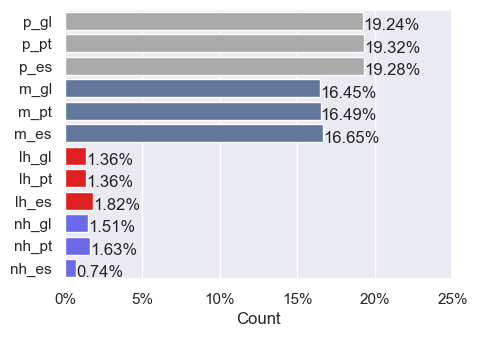

In [69]:
all_colors = {
'p_gl': '#aaaaaa',
'p_pt': '#aaaaaa',
'p_es': '#aaaaaa',
'm_gl': '#5975a4',
'm_pt': '#5975a4',
'm_es': '#5975a4',
'lh_gl': '#ff0000',
'lh_pt': '#ff0000',
'lh_es': '#ff0000',
'nh_gl': '#5555ff',
'nh_pt': '#5555ff',
'nh_es': '#5555ff'
}

all_colors = list(all_colors.values())
sns.set_palette(sns.color_palette(all_colors))
 
fig, ax = plt.subplots()
ax = sns.barplot(x="length", y="item", data=p_m_nh_lh_stats)
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0,decimals=0))
ax.set(xlim=(0, 0.25))
show_values_on_bars_h(ax)
fig.set_size_inches(5, 3.5)
ax.set(xlabel="Count", ylabel="")

[Text(0.5, 0, 'Count'), Text(0, 0.5, '')]

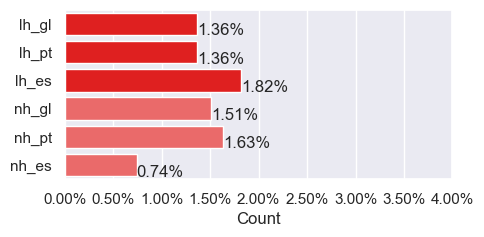

In [70]:
all_colors = {
'lh_gl': '#ff0000',
'lh_pt': '#ff0000',
'lh_es': '#ff0000',
'nh_gl': '#ff5555',
'nh_pt': '#ff5555',
'nh_es': '#ff5555'
}

all_colors = list(all_colors.values())
sns.set_palette(sns.color_palette(all_colors))

fig, ax = plt.subplots()
ax = sns.barplot(x="length", y="item", data=p_m_nh_lh_stats[6:16])
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.set(xlim=(0, 0.04))
show_values_on_bars_h(ax)
fig.set_size_inches(5, 2.2)
ax.set(xlabel="Count", ylabel="")

[Text(0.5, 0, 'Count'), Text(0, 0.5, '')]

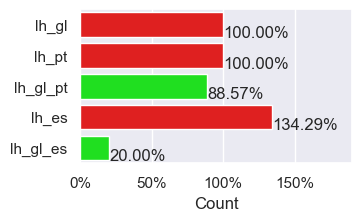

In [71]:
all_colors = {
'lh_gl': '#ff0000',
'lh_pt': '#ff0000',
'lh_gl_pt': '#00ff00',
'lh_es': '#ff0000',
'lh_gl_es': '#00ff00'
}

all_colors = list(all_colors.values())
sns.set_palette(sns.color_palette(all_colors))

fig, ax = plt.subplots()
ax = sns.barplot(x="length", y="item", data=lh_stats)
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.set(xlim=(0, 1.9))
show_values_on_bars_h(ax)
fig.set_size_inches(3.5, 2)
ax.set(xlabel="Count", ylabel="")

[Text(0.5, 0, 'Count'), Text(0, 0.5, '')]

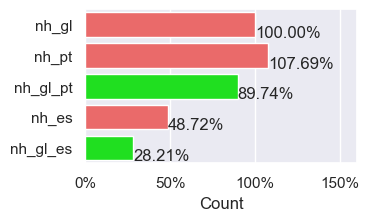

In [72]:
all_colors = {
'nh_gl': '#ff5555',
'nh_pt': '#ff5555',
'nh_gl_pt': '#00ff00',
'nh_es': '#ff5555',
'nh_gl_es': '#00ff00'
}

all_colors = list(all_colors.values())
sns.set_palette(sns.color_palette(all_colors))

fig, ax = plt.subplots()
ax = sns.barplot(x="length", y="item", data=nh_stats)
ax.xaxis.set_major_formatter(ticker.PercentFormatter(1.0))
ax.set(xlim=(0, 1.6))
show_values_on_bars_h(ax)
fig.set_size_inches(3.5, 2)
ax.set(xlabel="Count", ylabel="")